<p align="center">
  <img src="https://raw.githubusercontent.com/paulmunozpauta/Hidrology_Course/main/Static/Imgs/UdeC_color_horizontal.jpg" width="500">
</p>
<p align="center"><b style="font-size:28px;">Facultad de Ingeniería Agrícola</b></p>
<p align="center"><b style="font-size:28px;">Curso de Hidrología</b></p>
<hr>
<p align="center"><b style="font-size:28px;">Contacto</b></p>
<p align="center">
  paulmunoz@udec.cl<br>
  https://paulmunoz.com
</p>

# Precipitación

## Objetivo

Procesar datos pluviométricos de una estación real en Chile.


## Clonar el repositorio desde GitHub

In [1]:
# Clonar el repositorio desde GitHub
!git clone -- https://github.com/paulmunozpauta/Hidrology_Course

Cloning into 'Hidrology_Course'...
remote: Enumerating objects: 117, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 117 (delta 35), reused 23 (delta 6), pack-reused 38 (from 1)
Receiving objects: 100% (117/117), 63.05 MiB | 10.66 MiB/s, done.
Resolving deltas: 100% (41/41), done.


Después de ejecutar la celda anterior, se crea una carpeta en nuestro entorno llamada:

**Hidrology_Course**

Esta carpeta contiene todos los archivos del curso.

Ahora debemos entrar a esa carpeta para trabajar con los datos.

# Entrar a la carpeta del repositorio





In [2]:
# Entrar a la carpeta del repositorio
%cd Hidrology_Course
!ls

/content/Hidrology_Course
01_Delimitacion_cuenca.ipynb	   03_Precipitación.ipynb  README.md
02_Probabilidad_estadística.ipynb  Data			   Static


##Instalación e importación de librerías


Librerías principales:
pandas
numpy
matplotlib

In [3]:
# Instalar librerías necesarias
!pip -q install pandas

In [4]:
#Importar librerías
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Lectura  de datos hidrometerológicos

Los datos a usar están disponibles de forma libre en: https://explorador.cr2.cl/

Vamos a usar los datos de la estación Puerto Montt de la Dirección General de Aguas de Chile (10425001)

In [8]:
# ruta relativa del archivo en el repositorio
archivo = "Data/Precipitación/PuertoMontt_DGA_10425001.xlsx"
# leer el archivo Excel original de la DGA
PMontt = pd.read_excel(archivo)
PMontt

,agno,mes,dia,valor
0,1973,2,1,0.0
1,1973,2,2,0.0
2,1973,2,3,0.0
3,1973,2,4,0.0
4,1973,2,5,0.0
...,...,...,...,...
17477,2025,4,22,0.2
17478,2025,4,23,0.2
17479,2025,4,24,2.3
17480,2025,4,25,3.7


# Preprocesamiento (preparación) de datos para los análisis

Los datos diarios de esta estación están separados en columnas por "agno", "mes", "día" y "valor".

Vamos a generar una serie (dataframe) ordenada cronológicamente a través de la fecha disponible

In [11]:
# limpiar nombres de columnas
PMontt.columns = PMontt.columns.str.strip().str.lower()

# renombrar por seguridad si vienen con espacios o acentos raros
PMontt = PMontt.rename(columns={
    "agno": "anio",
    "año": "anio",
    "mes": "mes",
    "dia": "dia",
    "valor": "precipitacion_diaria_mm"
})

# convertir columnas a numéricas
for col in ["anio", "mes", "dia", "precipitacion_diaria_mm"]:
    PMontt[col] = pd.to_numeric(PMontt[col], errors="coerce")

# eliminar filas con datos faltantes en columnas clave
PMontt = PMontt.dropna(subset=["anio", "mes", "dia", "precipitacion_diaria_mm"])

# convertir año, mes y día a enteros
PMontt["anio"] = PMontt["anio"].astype(int)
PMontt["mes"] = PMontt["mes"].astype(int)
PMontt["dia"] = PMontt["dia"].astype(int)

# crear columna fecha
PMontt["fecha"] = pd.to_datetime(
    dict(year=PMontt["anio"], month=PMontt["mes"], day=PMontt["dia"]),
    errors="coerce"
)

# eliminar fechas inválidas
PMontt = PMontt.dropna(subset=["fecha"])

# dejar solo la serie temporal final
PMontt = PMontt[["fecha", "precipitacion_diaria_mm"]].copy()

# ordenar por fecha
PMontt = PMontt.sort_values("fecha").reset_index(drop=True)

# opcional: usar fecha como índice
PMontt = PMontt.set_index("fecha")

# mostrar la serie
PMontt


,precipitacion_diaria_mm
fecha,
1973-02-01,0.0
1973-02-02,0.0
1973-02-03,0.0
1973-02-04,0.0
1973-02-05,0.0
...,...
2025-04-22,0.2
2025-04-23,0.2
2025-04-24,2.3


## Figura de de precipitación diaria



Graficar esta serie preprocesada mediante barras, ya que la precipitación es una acumulación en cada día

<Figure size 1200x500 with 0 Axes>

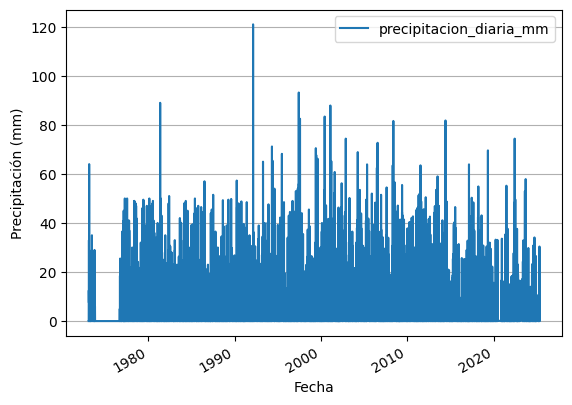

In [13]:
plt.figure(figsize=(12,5))

ts.plot()
plt.xlabel("Fecha")
plt.ylabel("Precipitación (mm)")
plt.grid(axis="y")

plt.show()
